# Taller EDA (Explotaroty Data Analysis)
**Alumna**: Abril Gabriela de los Angeles Sanchez Perez
----------------
Dataset usado: https://www.kaggle.com/datasets/noopurbhatt/retail-sales-dataset

In [2]:
# Importar librerías necesarias para el ejercicio (Pandas, Matplotlib y Seaborn)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Se realizará el cargue del dataset 'Retail Sales' usando la funcion read_csv y estableciendolo como df (data frame)

df = pd.read_csv(r"C:\Users\mcraz\DATASCIENCE  Curso\retail_sales_dataset.csv")

## Conocer la información del Dataset

Haré uso de las siguientes funciones principalmente para saber con que información estamos trabajando:

1. shape = para conocer cuantas filas y columnas tiene el dataset
2. dtypes = para obtener el tipo de dato de columna en el dataset


In [3]:
# Forma del dataset, usando la funcion shape (filas, columnas)
df.shape

(120000, 17)

In [4]:
# Tipo de datos encontrados por columna, usando la funcion dtypes
df.dtypes

transaction_id         object
transaction_date       object
customer_id            object
customer_gender        object
customer_age_group     object
customer_segment       object
product_id             object
product_name           object
category               object
brand                  object
quantity                int64
unit_price            float64
discount_pct            int64
sales_amount          float64
payment_method         object
sales_channel          object
region                 object
dtype: object

## Informacion específica del Data Set

De acuerdo a la información ya obtenida haré un análisis de los valores que tiene el dataset usando las siguientes funciones:

3. nunique : Para obtener la informacion de valores únicos dentro de las columnas
4. describe : Para saber que tipo de operaciones (promedio, min, max, etc. ) puedo sacar de cada columna, esto servirá para, más adelante, hacer las graficas correspondientes
a cada tipo de dato.

In [5]:
# 3. Valores unicos
df.nunique()

transaction_id        120000
transaction_date         730
customer_id            24784
customer_gender            3
customer_age_group         5
customer_segment           4
product_id               120
product_name              40
category                   8
brand                      3
quantity                   5
unit_price               120
discount_pct               7
sales_amount            3682
payment_method             5
sales_channel              3
region                     5
dtype: int64

In [6]:
# 4. Estadisticas por columna
df.describe()

,quantity,unit_price,discount_pct,sales_amount
count,120000.000000,120000.000000,120000.000000,120000.000000
mean,1.662908,240.621785,5.496500,377.975454
std,1.014291,146.457057,8.193257,356.893357
min,1.000000,7.730000,0.000000,5.410000
25%,1.000000,102.010000,0.000000,136.860000
50%,1.000000,238.750000,0.000000,295.980000
75%,2.000000,379.000000,10.000000,461.500000
max,5.000000,493.510000,30.000000,2467.550000


## Identificando Datos con Errores

*Para poder identificar que errores existen **antes** de hacer las graficas y de acuerdo a lo solicitado, usaré las siguientes funciones*

1. Nulos : `isnull().sum()` *esto para poder tener un resumen de cuantos datos nulos hay por columna*
2. Duplicados : `duplicated().sum()` *de la misma forma que los valores nulos, pero con las filas, para poder saber que valores se duplicaron en estas*

In [7]:
# Valores Nulos por Columna
df.isnull().sum()   

transaction_id        0
transaction_date      0
customer_id           0
customer_gender       0
customer_age_group    0
customer_segment      0
product_id            0
product_name          0
category              0
brand                 0
quantity              0
unit_price            0
discount_pct          0
sales_amount          0
payment_method        0
sales_channel         0
region                0
dtype: int64

In [8]:
# Valores duplicados en las filas
df.duplicated().sum()

np.int64(0)

## Graficas Escogidas 

***OJO: teniendo en cuenta que los datos no se encuentran duplicados, ni tampoco estan vacíos***

Para poder continuar con el punto del taller y saber que categorías estaban mal escritas, no estandarizadas o simplemente no me decían algo de acuerdo a la columna a la que pertenecian
quise primero escoger a donde se iba a centrar las gráficas, para esto dividí tres resultados que quiero obtener: 

1. De acuerdo al grupo de edad, cuales gastan mas (Usando las columnas customer_age_group y 'sales_amount') *Esto debido a que la columna de customer_age_group podría tener datos que no estén estandarizados* 
2. De acuerdo al tipo de genero, cual era la categoria mas vendida (Usando las columnas customer_gender y category pero segmentandolas sólo con un tipo de genero, en nuestro ejemplo 'Female') *Esto debido a que pueden haber datos que esten mal escrito generando una duplicación innecesaria del dato*
3. De acuerdo a la región, que tipo de canal de ventas usan (Usando las columnas region y sales_channel) *Al igual que el punto dos, puede que por error de digitación, haya un dato que esté generando una duplicación innecesaria* 

## Grafica # 1: ¿Que grupo de edad gasta más dentro de la tienda?

Usando la función sum() y groupby podré saber que grupo de edad gasta más, esto haciendo uso de un gráfico basico como lo es el de barras o 'bar', usaremos la biblioteca plt, pero primero debo saber con que datos estoy trabajando y si están todos estandarizados

In [9]:
# Usando la funcion df.unique() pero agregando que columna quiero analizar. Conoceré si todo está estandarizado en la columna 'customer_age_group'
df['customer_age_group'].unique()

array(['35-44', '45-54', '55+', '25-34', '18-24'], dtype=object)

In [10]:
# Agrupacion de los datos.

gasto_por_edad = df.groupby('customer_age_group')['sales_amount'].sum()
gasto_por_edad # Esto para visualizar que datos tenemos en esta agrupacion

customer_age_group
18-24    8969430.92
25-34    9039895.91
35-44    9170231.38
45-54    9091969.39
55+      9085526.85
Name: sales_amount, dtype: float64

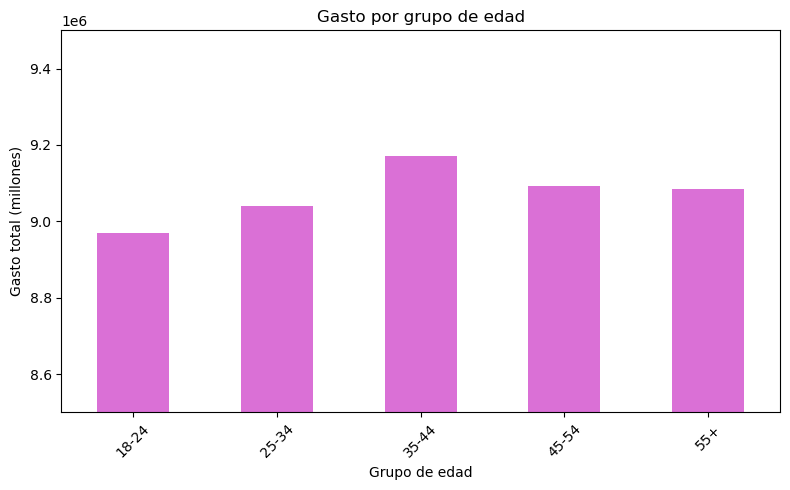

In [11]:
# Grafica de barras para visualizar el gasto por grupo de edad

gasto_por_edad.plot(kind='bar', figsize=(8, 5), color='orchid') # Donde kind = tipo de grafica, figsize = tamaño de la grafica en pulgadas, color = color de las barras

plt.title('Gasto por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Gasto total (millones)')
plt.ylim(8500000,9500000) # Como estamos usando valores numericos, es necesario limitar el eje y para visualizarlo de manera mas entendible
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Conclusion Grafico 1

El grupo que mas incurre en gastos dentro de esta tienda en particular son las personas entre 35 y 44 años, teniendo gastos entre los 9.1y 9.2 millones en comparacion a las demas categorías. 

De manera más tecnica, para este tipo de graficos (en donde tenemos valores que expresan cifras numericas) es necesario limitar el eje en donde están (en mi caso el eje y) para que esté de forma más entendible.  

## Grafico # 2 Categoria Mas Comprada por el genero Femenino
Los pasos para explorar este gráfico serán los mismos que use en la primera grafica esta vez con las columnas 'customer_gender' y 'category'
y haré una segmentación para la grafica en donde solo se muestre que categorias compraron mas las mujeres

In [12]:
print("Tipos de género encontrados en la columna 'customer_gender':")
print(df['customer_gender'].unique())

print("Categorías encontradas en la columna 'category':")
print(df['category'].unique())

Tipos de género encontrados en la columna 'customer_gender':
['Other' 'Male' 'Female']
Categorías encontradas en la columna 'category':
['Sports' 'Clothing' 'Beauty' 'Groceries' 'Toys' 'Home' 'Books'
 'Electronics']


In [13]:
# Viendo que no hay ningun dato que genere duplicaciosn innecesaria, procederé a realizar una grafica tipo torta para saber que categoria compraron mas las mujeres

# Primero, filtrare la columna de 'customer_gender' para que solo quede 'Female'

datos_mujeres = df[df['customer_gender'] == 'Female']

# Ahora para poder obtener el dato exacto de que categorias compraron mas, haré la misma segmentacion con la columna 'category' donde mi dato principal sera "datos_mujeres" usando la funcion value_counts()

compras_mujeres = datos_mujeres['category'].value_counts()

# Resultado obtenido:
print(compras_mujeres)

category
Beauty         5133
Clothing       5084
Toys           5067
Sports         5051
Groceries      5050
Home           5032
Electronics    5018
Books          4833
Name: count, dtype: int64


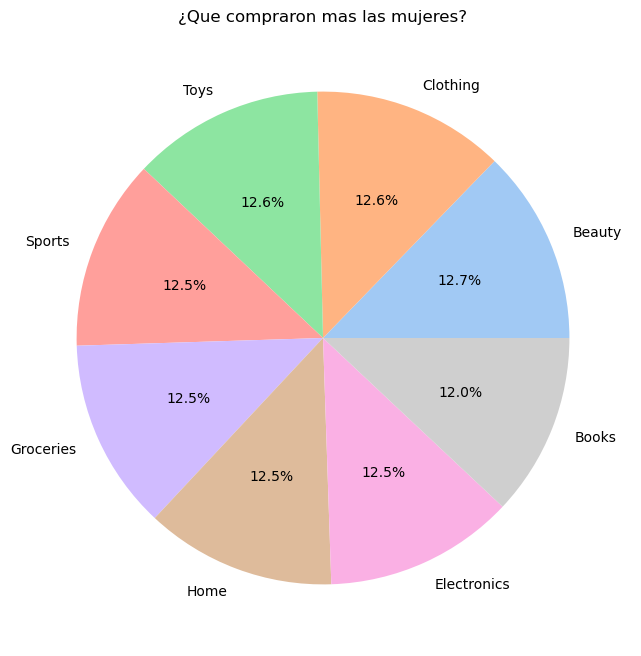

In [14]:
## Ahora procedere a realizar la grafica tipo torta, en matplotlib el kind será pie

compras_mujeres.plot(kind='pie', autopct='%1.1f%%', figsize=(8, 8), colors=sns.color_palette('pastel')) # Donde autopct = formato del porcentaje, colors = paleta de colores (https://matplotlib.org/stable/users/explain/colors/colormaps.html)
plt.title ('¿Que compraron mas las mujeres?')
plt.ylabel('') # Para eliminar la etiqueta del eje y
plt.show()

## Conclusiones Grafica 2:

De manera técnica y cuando tenemos información que pueda tener casi el mismo porcentaje, el gráfico de torta
sirve para poder saberen que porcentaje puede distinguirse. 

Así mismo, es importante que, al hacer este gráfico eliminemos la etiqueta dentro del eje Y y así evitar confusiones

## Grafico #3: Canal de Ventas usado por Region

Haciendo uso de la librería seaborn y tomando la información de las columnas region y sales_channel, procederemos a graficar haciendo uso de la gráfica heatmap. 

Este funciona como un semaforo pero entre más oscuro sea el color que muestra el numero al que hace referencia será mas alto y viceversa, si el color que muestra es más clarito es porque el número al que referencia es más bajo entre los que muestra.

La idea es poder obtener todo agrupado en una tabla y, haciendo uso del resultado obtenido por cada tabla, podremos mirarlo dentro de la gráfica (heatmap)

In [19]:
# Paso 1. Revisar los tipos de datos únicos que hay dentro de los datos seleccionados

print(df['region'].unique())
print(df['sales_channel'].unique())

['North' 'South' 'Central' 'East' 'West']
['Online' 'In-Store' 'Mobile App']


In [17]:
# Paso 2. Limpieza y agrupacion del data set para poder obtener datos claros y no un desorden en la visualizacion
# Hare una tabla en donde pueda agrupar (usando groupby) el # de transacciones por region y canal de  venta. 

info_heatmap = df.groupby(['region','sales_channel']).size().unstack() 
# Haciendo un poco de explicacion, usé size para contar cuantas transacciones incurrieron por cada grupo (Ej: North-Mobile App)
# Mientras que unstack me permité convertir todo en una tabla donde: filas = region, columnas = sales_channel y el valor mostrado será ese conteo realizado en size()
print(info_heatmap)

sales_channel  In-Store  Mobile App  Online
region                                     
Central            8023        8146    8075
East               7836        7935    7894
North              8090        7997    7988
South              7969        8054    8043
West               8131        8072    7747


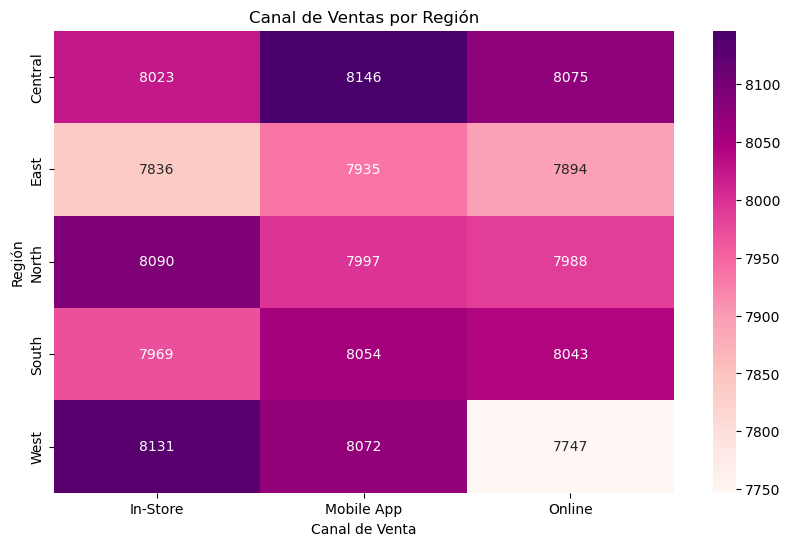

In [18]:
# Paso 3. Hacer el heatmap con seaborn. 
# Haciendo uso de la info obtenida en la tabla, procederé a construir el heatmap. 

plt.figure(figsize=(10, 6))

sns.heatmap(info_heatmap, annot=True, fmt='d', cmap='RdPu') # Donde annot = muestra valores, fmt = formato de los valores (aca, enteros), cmap = paleta de colores

plt.title('Canal de Ventas por Región')
plt.xlabel('Canal de Venta')
plt.ylabel('Región')
plt.show()

## Conclusion Gráfica #3

Como lo expliqué al inicio de esta gráfica, la idea es que el heatmap muestre en su color más oscuro cuál es el valor mas alto de todos los obtenidos y en el más claro cuál es el más bajo que obtuvo.

Para este ejercicio en donde necesitaba saber el dato del canal más usado en todas las regiones, el heatmap me permite mirar de forma más visual *(por así decirlo)* cuál es el uso de cada región de forma rápida. 

Por ejemplo, puedo decir que  región Norte hay un uso igual de la app movil y el canal online pero que los compradores preferirán ir directamente a la tienda a hacer su compra. No necesito saber exactamente que número lo hace pero el color ya lo dice todo.

--- Fin del Taller